# Lab 1: Data and Embeddings

This notebook introduces the dataset and illustrates how the raw inputs are structured. Notebooks 2 and 3 are fully self-contained and do not depend on this one.
## Background

The data come from Amazon.com and cover toy products observed between March 2023 and January 2024. For each product, we observe monthly snapshots of the sales rank and the buy-box price, together with product descriptions and images. The dataset contains approximately 7,000 unique products tracked over 12 four-week periods.

## Notation and Variable Definitions

Let $i$ index products and $t$ index time periods. The two central variables are defined as follows.

**Quantity signal.** Amazon does not publish unit sales directly. We use the sales rank as a proxy. Higher sales rank means fewer units sold, so we invert it. The quantity signal is
$$Q_{it} = \log\!\bigl(1/\text{Time-Averaged Sales Rank of } i \text{ in period } t\bigr).$$
A higher value of $Q_{it}$ corresponds to a product selling more units relative to competitors in the category.

**Price signal.** The buy-box price is the price shown to buyers considering immediate purchase. We transform it as
$$P_{it} = \log\!\bigl(\text{Time-Averaged Price of } i \text{ in period } t\bigr).$$
Working in logs means that regression coefficients can be interpreted as approximate elasticities.

**Remark (Pareto interpretation).** Under a Pareto distribution with shape parameter $\vartheta$ for units sold, the price sensitivity of actual demand is approximately $1/\vartheta$ times the rank elasticity.With $\hat{\vartheta} \approx 0.5$ for toys on Amazon, multiplying rank elasticity estimates by $1/\hat{\vartheta} \approx 2$ gives approximate demand elasticities.

## Raw Inputs and Embeddings

Each product has a multimodal input vector $X^{in}_i = [\text{Text}_i,\; \text{Image}_i, \text{Tabular}_i]^T$. The text description, image and tabular data are passed through transformer-based models (RoBERTa for text, BEiT for images, SAINT for Tabular), producing embeddings $E_i$. These are compressed to 256 dimensions via a Johnson-Lindenstrauss random projection, yielding $\bar{E}_i \in \mathbb{R}^{256}$.

The projected embeddings are centered and normalized to the unit hypersphere:
$$X^e_i := \frac{\bar{E}_i - n^{-1}\sum_j \bar{E}_j}{\bigl\|\bar{E}_i - n^{-1}\sum_j \bar{E}_j\bigr\|}.$$
These vectors serve as rich product-level controls that capture quality, style, and category information not available in structured form.

Because the raw embedding space is high-dimensional, we summarize it in two ways for use in regression:
- **PCA projections**: $X^{pc}_{i,k} := \gamma_k^T X^e_i$ for $k = 1, \ldots, K$, where $\gamma_k$ is the $k$-th eigenvector of the covariance matrix of $X^e_i$.
- **Cluster similarities**: $X^{sim}_{i,k} := c_k^T X^e_i$ for $k = 1, \ldots, K$, where $c_k$ is the centroid of the $k$-th cluster from k-means with $K = 5$. Since $X^e_i$ lies on the unit hypersphere, the inner product represents cosine similarity.

These summaries play a central role in the causal estimation in Lab 3.

In [ ]:
import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

palette = sns.color_palette("colorblind")

## Loading the Dataset

The dataset is hosted on GitHub. It is split into a training set and a test set. We use this split throughout all three labs.

In [ ]:
df_train = pd.read_csv(r"https://github.com/JanTeichertKluge/demand-analysis-repro/raw/refs/heads/main/main/data/dataset_txt_only_False_embeddings_True_train.zip")
df_test = pd.read_csv(r"https://github.com/JanTeichertKluge/demand-analysis-repro/raw/refs/heads/main/main/data/dataset_txt_only_False_embeddings_True_val.zip")

ds = datasets.DatasetDict()
ds["train"] = datasets.Dataset.from_pandas(df_train)
ds["test"] = datasets.Dataset.from_pandas(df_test)

ds_train = ds["train"]
ds_test  = ds["test"]
print(f"\nTrain: {len(ds_train):,} observations")
print(f"Test:  {len(ds_test):,} observations")


Train: 41,945 observations
Test:  41,832 observations


In [ ]:
all_cols = ds_train.column_names
emb_cols = sorted([c for c in all_cols if c.startswith("emb_")])
other_cols = [c for c in all_cols if c not in emb_cols]

print(f"Embedding dimensions:  {len(emb_cols)}")
print(f"Structured variables:  {len(other_cols)}")
print("\nStructured columns:")
for c in other_cols:
    print(" ", c)

Embedding dimensions:  256
Structured variables:  92

Structured columns:
  ASIN
  date
  index
  Q_t
  PRICE
  P_bb_t
  text
  window
  REVIEW_COUNT
  RATING
  New Offer Count: Current
  Count of retrieved live offers: New, FBA
  Count of retrieved live offers: New, FBM
  Lightning Deals: Upcoming Deal
  Buy Box: Is FBA
  subcat_aggregated
  date_t
  Airplanes
  Cars & Race Cars
  Motor Vehicles
  Race Tracks
  Residual
  Skateboards
  Tractors
  Train Sets
  Trains & Trams
  Trucks
  Vehicle Playsets
  2023-01-30
  2023-02-27
  2023-03-27
  2023-04-24
  2023-05-22
  2023-06-19
  2023-07-17
  2023-08-14
  2023-09-11
  2023-10-09
  2023-11-06
  2023-12-04
  2024-01-01
  2024-01-29
  Airplanes.1
  Cars & Race Cars.1
  Motor Vehicles.1
  Race Tracks.1
  Residual.1
  Skateboards.1
  Tractors.1
  Train Sets.1
  Trains & Trams.1
  Trucks.1
  Vehicle Playsets.1
  pca_0
  pca_1
  pca_2
  pca_3
  pca_4
  similarity_cluster_0
  similarity_cluster_1
  similarity_cluster_2
  similarity_cluster_3


In [ ]:
df_train = ds_train.to_pandas()
df_test  = ds_test.to_pandas()

df_train[["ASIN", "date", "Q_t", "P_bb_t"]].head()

,ASIN,date,Q_t,P_bb_t
0,1947335162,2023-01-30,-12.747395,3.555062
1,1947335162,2023-02-27,-12.600586,3.555062
2,1947335162,2023-03-27,-12.515369,3.633271
3,1947335162,2023-04-24,-12.576837,3.582963
4,1947335162,2023-05-22,-12.688608,3.587493


## Descriptive Statistics

We look at the distributions of the quantity and price signals and the number of products per subcategory.

In [ ]:
df_train[["Q_t", "P_bb_t", "REVIEW_COUNT", "RATING"]].describe().round(3)

,Q_t,P_bb_t,REVIEW_COUNT,RATING
count,41945.000,41945.000,41945.000,41945.000
mean,-11.121,3.042,851.247,4.497
std,1.301,0.625,2871.775,0.362
min,-14.169,1.356,-1.000,1.000
25%,-12.042,2.638,29.464,4.325
50%,-11.364,2.995,147.214,4.600
75%,-10.427,3.386,633.000,4.700
max,-2.969,7.473,100314.357,5.000


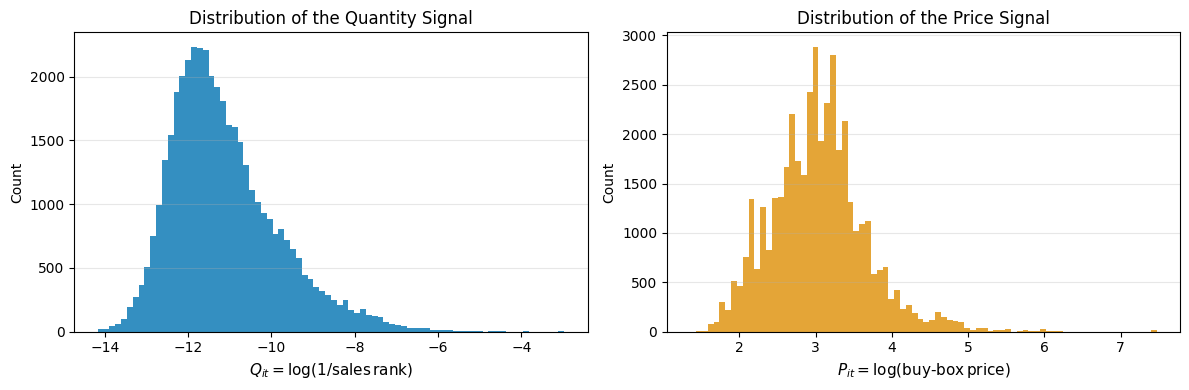

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_train["Q_t"].dropna(), bins=80, color=palette[0], alpha=0.8, edgecolor="none")
axes[0].set_xlabel("$Q_{it} = \\log(1/\\mathrm{sales\\, rank})$", fontsize=11)
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of the Quantity Signal")
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist(df_train["P_bb_t"].dropna(), bins=80, color=palette[1], alpha=0.8, edgecolor="none")
axes[1].set_xlabel("$P_{it} = \\log(\\mathrm{buy\\text{-}box\\, price})$", fontsize=11)
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of the Price Signal")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
if "subcat_aggregated" in df_train.columns:
    print("Products per subcategory (training set):")
    print(df_train.groupby("subcat_aggregated")["ASIN"].nunique().sort_values(ascending=False).to_string())

Products per subcategory (training set):
subcat_aggregated
Cars & Race Cars    1205
Trucks               678
Residual             639
Skateboards          335
Train Sets           308
Vehicle Playsets     131
Airplanes            113
Race Tracks          112
Motor Vehicles       102
Trains & Trams        91
Tractors              60


## Embedding Structure

The concatenated embeddings $E_i = (T_i, I_i)$ are compressed via Johnson-Lindenstrauss projection to $\bar{E}_i \in \mathbb{R}^{256}$, then centered (subtract training mean) and L2-normalized to the unit hypersphere:
$$X^e_i := \frac{\bar{E}_i - n^{-1}\sum_j \bar{E}_j}{\bigl\|\bar{E}_i - n^{-1}\sum_j \bar{E}_j\bigr\|}.$$

We then apply PCA to visualize the main axes of variation. The PCA projections are $X^{pc}_{i,k} := \gamma_k^T X^e_i$, where $\gamma_k$ is the $k$-th eigenvector of the covariance matrix of $X^e_i$.

Normalizing to unit length ensures that all products are compared by direction rather than magnitude, which is standard practice when working with transformer embeddings.

In [ ]:
emb_tr = df_train[emb_cols].values.astype(float)
emb_te = df_test[emb_cols].values.astype(float)

global_mean = emb_tr.mean(axis=0)
emb_tr_n = normalize(emb_tr - global_mean, axis=1)
emb_te_n = normalize(emb_te - global_mean, axis=1)

pca3 = PCA(n_components=3, random_state=42)
pca3.fit(emb_tr_n)

print("Variance explained by PCA components:")
for i, ev in enumerate(pca3.explained_variance_ratio_):
    cumulative = pca3.explained_variance_ratio_[:i+1].sum()
    print(f"  PC{i+1:2d}:  {ev:.3f}  (cumulative: {cumulative:.3f})")

Variance explained by PCA components:
  PC 1:  0.233  (cumulative: 0.233)
  PC 2:  0.204  (cumulative: 0.437)
  PC 3:  0.052  (cumulative: 0.490)


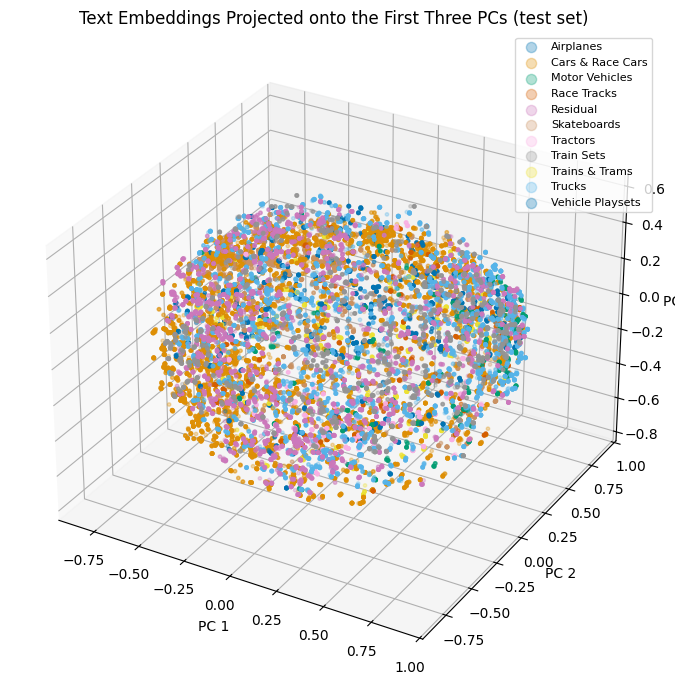

In [ ]:
coords = pca3.transform(emb_te_n)

if "subcat_aggregated" in df_test.columns:
    cats = df_test["subcat_aggregated"].astype("category")
    codes = cats.cat.codes.values
else:
    cats  = pd.Categorical(["all"] * len(coords))
    codes = np.zeros(len(coords), dtype=int)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
for i, cat in enumerate(cats.cat.categories):
    mask = codes == i
    ax.scatter(coords[mask, 0], coords[mask, 1], coords[mask, 2],
               label=cat, alpha=0.3, s=6, color=palette[i % len(palette)])
ax.set_xlabel("PC 1", fontsize=10)
ax.set_ylabel("PC 2", fontsize=10)
ax.set_zlabel("PC 3", fontsize=10)
ax.set_title("Text Embeddings Projected onto the First Three PCs (test set)")
ax.legend(markerscale=3, fontsize=8, loc="best")
plt.tight_layout()
plt.show()

## K-Means Clustering

We fit a k-means model with $K = 5$ clusters to the normalized training embeddings. The resulting centroids $c_1, \ldots, c_K$ define the similarity variables used in the regression models. The $k$-th similarity score for product $i$ is
$$X^{sim}_{i,k} := c_k^T X^e_i, \quad k = 1, \ldots, K.$$
Since $X^e_i$ lies on the unit hypersphere, the inner product $c_k^T X^e_i$ directly represents cosine similarity (up to normalization of $c_k$). The resulting compressed vector $X^{sim}_i = (X^{sim}_{i,k})_{k=1}^K \in \mathbb{R}^K$ enters the control function in Labs 2 and 3.

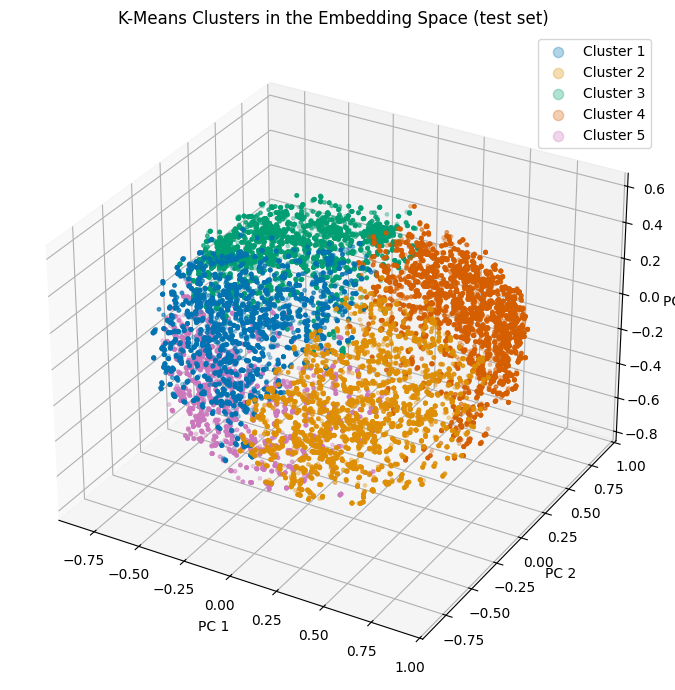

Products per cluster (test set):
  Cluster 1: 8,003
  Cluster 2: 9,292
  Cluster 3: 9,011
  Cluster 4: 10,956
  Cluster 5: 4,570


In [ ]:
km = KMeans(n_clusters=5, random_state=42, n_init=50)
labels = km.fit_predict(emb_te_n)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
for k in range(5):
    mask = labels == k
    ax.scatter(coords[mask, 0], coords[mask, 1], coords[mask, 2],
               label=f"Cluster {k+1}", alpha=0.3, s=6, color=palette[k])
ax.set_xlabel("PC 1", fontsize=10)
ax.set_ylabel("PC 2", fontsize=10)
ax.set_zlabel("PC 3", fontsize=10)
ax.set_title("K-Means Clusters in the Embedding Space (test set)")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

print("Products per cluster (test set):")
for k in range(5):
    print(f"  Cluster {k+1}: {(labels == k).sum():,}")

In [ ]:
# We pick the first occurrence to keep things deterministic.
first_idx = df_test.drop_duplicates(subset="ASIN").index.to_numpy()
emb_te_n_unique = emb_te_n[first_idx]
coords_unique   = coords[first_idx]

# Distances from the unique products to each centroid
distances = km.transform(emb_te_n_unique)        # (n_unique, K)
n_show = 5
closest_local = {k: np.argsort(distances[:, k])[:n_show] for k in range(5)}
# Map back to original df_test row indices for plotting & metadata
closest_idx   = {k: first_idx[closest_local[k]]  for k in range(5)}

# Metadata
meta_cols_show = [c for c in ["ASIN", "subcat_aggregated", "text"]
                  if c in df_test.columns]

In [ ]:
print("Cluster 0")
df_test.loc[closest_idx[0]][meta_cols_show]

Cluster 0


,ASIN,subcat_aggregated,text
6819,B0751HN5C9,Cars & Race Cars,Disney Pixar Cars Nigel Gearsley | Cars & Race...
41037,B0CF8H3T17,Trucks,"Qcar Pickup Truck Vehicles Toys, Diecast Metal..."
9964,B07NZ5237Z,Trucks,"Boley 8 Piece 14"" Safari Transport Truck Carri..."
10654,B07QPMX8CP,Residual,IPG for Vector Robot Face Screen Guard Decorat...
17971,B08R1262J7,Residual,Auto World PSC4G-029 4Gear HO Scale Electric S...


In [ ]:
print("Cluster 1")
df_test.loc[closest_idx[1]][meta_cols_show]

Cluster 1


,ASIN,subcat_aggregated,text
2117,B004NO00SG,Trucks,Bruder Mack Granite Garbage Truck (Ruby red-Gr...
19510,B08WWZXHY1,Trucks,Bruder - Mack Granite Tow Truck with Bruder Ro...
1337,B001DZLLDG,Trucks,Bruder Toys 02813 Mack Granite Flatbed Truck w...
7641,B07BDZTM4L,Train Sets,"Lionel Thomas & Friends Ready-to-Play Set, Bat..."
7070,B076JCP2TX,Trucks,Bruder Man Tgs Side Loading Garbage Truck Vehi...


In [ ]:
print("Cluster 2")
df_test.loc[closest_idx[2]][meta_cols_show]

Cluster 2


,ASIN,subcat_aggregated,text
3347,B00FYV7JR2,Trucks,Kinsmart Red 1955 Chevy Stepside Pick-Up Die C...
25720,B09PDF9NL8,Skateboards,"DIY-SCIENCE Mini Fingerboard Shoes, Mini Skate..."
6581,B074CNXJ3L,Residual,"KiNSMART 2016 Pagani Huayra White 5"" 1:38 Scal..."
4571,B016993FWA,Residual,KiNSMART 1967 Ford Shelby Mustang GT500 Red 1:...
13446,B083TK52CN,Skateboards,"DIY-SCIENCE Mini Finger Shoes for Fingerboard,..."


In [ ]:
print("Cluster 3")
df_test.loc[closest_idx[3]][meta_cols_show]

Cluster 3


,ASIN,subcat_aggregated,text
15732,B08FCQLHM1,Motor Vehicles,"Paw Patrol, True Metal Spark Gift Pack of 6 Co..."
35823,B0BSB29H3Q,Trucks,Smashers Monster Truck Surprise (Shark Truck) ...
15746,B08FCQRL9H,Motor Vehicles,"Paw Patrol, True Metal Chase Rescue Track Set ..."
40258,B0CBJM39WT,Trucks,HEGUD Toddler Car Toys for 1 2 3 4 Year Old Gi...
21663,B099P1QTG2,Cars & Race Cars,Stomp Rocket Stomp Racers Air Powered Race Car...


In [ ]:
print("Cluster 4")
df_test.loc[closest_idx[4]][meta_cols_show]

Cluster 4


,ASIN,subcat_aggregated,text
33605,B0BLJ5TD9B,Cars & Race Cars,Matchbox Dodge Charger Pursuit | Cars & Race C...
36635,B0BVRW952X,Cars & Race Cars,Matchbox 1970 Ford Ranchero 17/100 (Green) | C...
36642,B0BVRWM6L3,Cars & Race Cars,Matchbox 2021 Ford Bronco 25/100 (Mint Green) ...
34458,B0BNLXLBXB,Cars & Race Cars,Hot Wheels Retro Entertainment Forza '94 Audi ...
34053,B0BMWB576G,Cars & Race Cars,Matchbox 2022 - 2021 Ford Mustang MACH-E - Red...


## Naive Effect Estimation

In [ ]:
import statsmodels.api as sm

# Regress Q_t on P_bb_t

model = sm.OLS(df_test['Q_t'], sm.add_constant(df_test['P_bb_t']))
results = model.fit()
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                    Q_t   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     121.9
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           2.63e-28
Time:                        18:13:19   Log-Likelihood:                -70813.
No. Observations:               41832   AIC:                         1.416e+05
Df Residuals:                   41830   BIC:                         1.416e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.7484      0.032   -335.655      0.0

In [ ]:
# Regress Q_t on P_bb_t with tabular controls

tabular_controls = [
    "RATING", "REVIEW_COUNT",]
X = sm.add_constant(df_test['P_bb_t'])
for c in tabular_controls:
    X[c] = df_test[c]

# add subcategory dummies if available
if "subcat_aggregated" in df_test.columns:
    sub_te = pd.get_dummies(df_test["subcat_aggregated"], prefix="sub", drop_first=True).astype(int)
    X = pd.concat([X, sub_te], axis=1)

model = sm.OLS(df_test['Q_t'], X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    Q_t   R-squared:                       0.188
Model:                            OLS   Adj. R-squared:                  0.188
Method:                 Least Squares   F-statistic:                     746.7
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:13:19   Log-Likelihood:                -66508.
No. Observations:               41832   AIC:                         1.330e+05
Df Residuals:                   41818   BIC:                         1.332e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -11.1431 